# Importações e Carregamento dos Dados

In [1]:
# Importações de manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações de Machine Learning
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento e Limpeza

In [2]:
# Carregar o dataset
df = pd.read_csv('data/QuantumGateBench.csv')
print(f"Tamanho original do dataset: {len(df)} linhas")

# --- Limpeza Baseada em Limites Teóricos ---
condicao_fidelidade_valida = (df['fidelity'] >= -1) & (df['fidelity'] <= 1)
condicao_erro_valido = (df['error_rate'] >= 0) & (df['error_rate'] <= 1)

# Filtrando o DataFrame 
df_clean = df[condicao_fidelidade_valida & condicao_erro_valido].copy()

linhas_removidas = len(df) - len(df_clean)
print(f"Número de linhas inválidas removidas (erros de hardware/outliers): {linhas_removidas}")
print(f"Tamanho do dataset após a limpeza: {len(df_clean)} linhas")

Tamanho original do dataset: 26000 linhas
Número de linhas inválidas removidas (erros de hardware/outliers): 1005
Tamanho do dataset após a limpeza: 24995 linhas


# Análise Exploratória

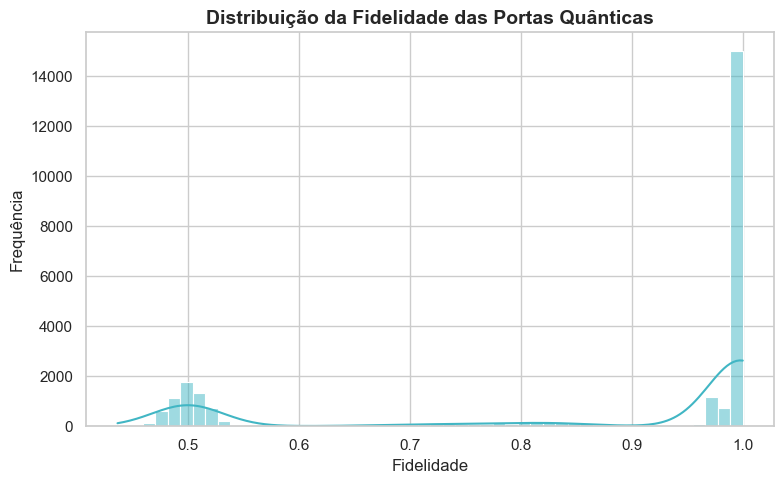

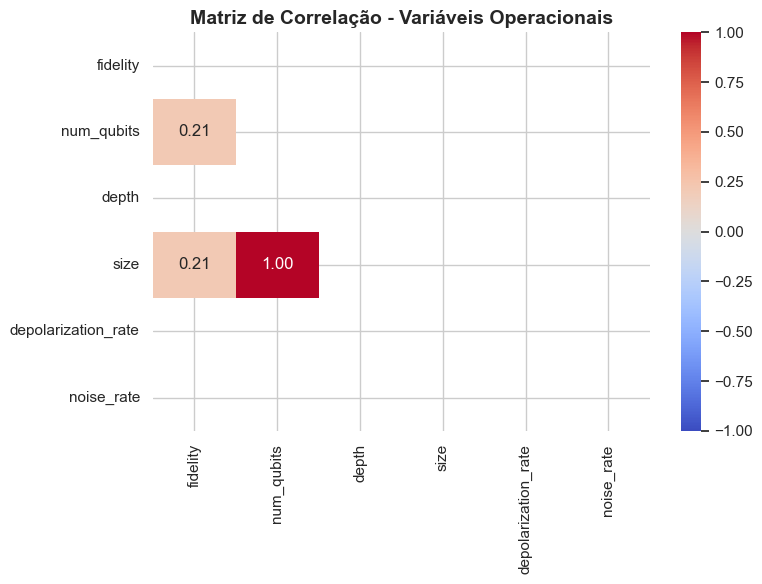

In [3]:
# Distribuição da Fidelidade
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['fidelity'], bins=50, kde=True, color='#41b6c4')
plt.title('Distribuição da Fidelidade das Portas Quânticas', fontsize=14, weight='bold')
plt.xlabel('Fidelidade', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.tight_layout()
plt.show()

# Matriz de Correlação das Variáveis Escolhidas
cols_numericas = ['fidelity', 'num_qubits', 'depth', 'size', 'depolarization_rate', 'noise_rate']
df_corr = df_clean[cols_numericas].corr()

plt.figure(figsize=(8, 6))

# Mostrar apenas a diagonal inferior para estética acadêmica
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação - Variáveis Operacionais', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Pré-processamento e Divisão dos Dados

In [4]:
# Definir as colunas de entrada (features)
features = ['gate', 'num_qubits', 'depth', 'size', 'depolarization_rate', 'noise_rate']
X = df_clean[features]
y = df_clean['fidelity']

# One-Hot Encoding para a variável categórica 'gate'
X_processed = pd.get_dummies(X, columns=['gate'], prefix='gate')

# Divisão Hold-out: 70% Treinamento / 30% Teste Inédito
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42)

print(f"Tamanho do conjunto de treinamento: {len(X_train)} linhas")
print(f"Tamanho do conjunto de teste (intocado): {len(X_test)} linhas")

Tamanho do conjunto de treinamento: 17496 linhas
Tamanho do conjunto de teste (intocado): 7499 linhas


# Treinamento, Validação no Treino e Avaliação Final

In [5]:
# Configuração do K-Fold (k=5) APENAS para os 70% de Treino
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário com os Modelos Otimizados
modelos = {
    'Regressão Linear': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42, early_stopping=True, n_iter_no_change=20))
    ]),
    'SVR Otimizado': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(C=100, epsilon=0.01, gamma='scale', kernel='rbf'))
    ])
}

resultados_finais = []

for nome, modelo in modelos.items():
    print(f"\n--- Processando: {nome} ---")
    
    # 1. Validação Cruzada (Apenas para relatório de estabilidade no treino)
    cv_results = cross_validate(modelo, X_train, y_train, cv=kf, scoring='r2')
    print(f"CV R² (Treino): {cv_results['test_score'].mean():.4f} ± {cv_results['test_score'].std():.4f}")
    
    # 2. Treinamento Final (Usando os 100% de X_train)
    modelo.fit(X_train, y_train)
    
    # 3. Predição Cega no Teste
    y_pred = modelo.predict(X_test)
    
    # 4. Cálculo das Métricas
    r2_final = r2_score(y_test, y_pred)
    mae_final = mean_absolute_error(y_test, y_pred)
    rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))
    
    resultados_finais.append({
        'Modelo': nome,
        'R² (Teste)': round(r2_final, 4),
        'MAE (Teste)': round(mae_final, 4),
        'RMSE (Teste)': round(rmse_final, 4)
    })

# Exibir os resultados para a Tabela 1
print("\n=== RESULTADOS FINAIS NO CONJUNTO DE TESTE (30%) ===")
df_resultados = pd.DataFrame(resultados_finais)
display(df_resultados)


--- Processando: Regressão Linear ---
CV R² (Treino): 0.9499 ± 0.0023

--- Processando: Random Forest ---
CV R² (Treino): 0.9499 ± 0.0023

--- Processando: XGBoost ---
CV R² (Treino): 0.9499 ± 0.0023

--- Processando: MLP ---
CV R² (Treino): 0.9497 ± 0.0023

--- Processando: SVR Otimizado ---
CV R² (Treino): 0.9122 ± 0.0042

=== RESULTADOS FINAIS NO CONJUNTO DE TESTE (30%) ===


,Modelo,R² (Teste),MAE (Teste),RMSE (Teste)
0,Regressão Linear,0.9446,0.0237,0.0494
1,Random Forest,0.9446,0.0237,0.0494
2,XGBoost,0.9446,0.0237,0.0494
3,MLP,0.9446,0.0246,0.0494
4,SVR Otimizado,0.8995,0.0286,0.0666
